# Tarefa 3 - Neural Networks Coursework 2026

Third assessed coursework for **Tecnicas e Algoritmos em Ciencia de Dados**.

Write your 6-digit anonymous identifier in the first code cell. Submit a single notebook named with that identifier, for example `568423.ipynb`. Do not submit datasets or extra Python scripts. Any helper function used by your solution must be included in this notebook.

This notebook is a guide. The TODO cells mark the parts you must implement. The TensorFlow baseline cells are provided so you can compare your own implementations against a standard neural-network baseline.

## Overview

1. Regression with neural networks (50%)
2. Multiclass classification with neural networks (50%)

## General rules

- You may use NumPy and basic libraries for matrix operations.
- You must not use library implementations for the algorithms you are asked to implement manually.
- Standardize features manually using only training-set statistics.
- Use the validation set for model selection.
- Use the test set only for final reporting.
- Restart the kernel and run the full notebook before submitting.


In [125]:
student_id = "145236"  # Replace with your 6-digit anonymous identifier.
student_id


'145236'

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, f1_score, accuracy_score, precision_recall_fscore_support

np.random.seed(0)


In [127]:
# Versions
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.3
NP: 2.4.6


# Helper Functions

Implement any shared helper functions here. In particular, you will need a function to standardize validation and test data using the mean and standard deviation computed from the training set.

Do not use `sklearn.preprocessing.StandardScaler` for this coursework requirement.


In [128]:
def standardize_from_train(X_train, X_val, X_test):
    """Standardize X_train, X_val, and X_test using training-set statistics only."""
    # DONE:
    # 1. Compute the mean of each feature using X_train.
    # 2. Compute the standard deviation of each feature using X_train.
    # 3. Replace any zero standard deviation with 1.0.
    # 4. Transform X_train, X_val, and X_test with the training mean/std.
    # 5. Return the three transformed arrays, plus the mean and std if useful.

    X_avg = np.mean(X_train, axis=0, keepdims=True)
    X_std = np.std(X_train, axis=0, keepdims=True)
    X_std[X_std == 0] = 1.0
    norm_train = (X_train - X_avg) / X_std

    norm_val = (X_val - X_avg) / X_std if (X_val is not None) else None
    norm_test = (X_test - X_avg) / X_std if (X_test is not None) else None

    return norm_train, norm_val, norm_test


def rmse(y_true, y_pred):
    """Return the root mean squared error."""
    # DONE: implement RMSE with NumPy.

    return np.mean((y_pred - y_true) ** 2) ** (1/2)


def multiclass_metrics(y_true_one_hot, predicted_probabilities, predicted_labels):
    """Compute AUROC, precision, F1, and accuracy for multiclass predictions."""
    # TODO: use sklearn metric functions for reporting only.
    # Hint: AUROC should use probabilities. Precision/F1/accuracy use predicted labels.
    raise NotImplementedError


# Part 1 - Regression With Neural Networks (50%)

## Dataset

Use `student_performance.csv`. Each row corresponds to a student. The target is `final_score`.

Required preprocessing:

1. Load the dataset.
2. Data cleaning, droping duplicates, and convert categorical variables to numerical variables.
3. Use `final_score` as the regression target.
4. Do not use `student_id` as a feature.
5. Do not use `passed` as a feature because it is derived from the final score.
6. Split the data into training, validation, and test sets using a 70:15:15 ratio.
7. Standardize features manually using only training-set statistics.


In [ ]:
performance = pd.read_csv("../../data/student_performance.csv")
display(performance.head())
display(performance.describe(include="all"))
print(performance.shape)


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


(500, 11)


In [130]:
# DONE: Regression preprocessing.
# - Convert categorical variables to numerical variables.
# - Set y to the final_score column.
# - Set X to the feature matrix after dropping student_id, final_score, and passed.

display(performance[performance.duplicated()]) # no duplicated rows
print(performance.isna().sum()) # NaN only on 'parent_education'
print(performance['parent_education'].unique())

# binary features are corect
print(performance['internet_access'].unique())
print(performance['extracurricular'].unique())

# Example variable names expected by later cells:
# X = ...
# y = ...



,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed


student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64
<StringArray>
['Bachelor', 'High School', 'Master', nan, 'PhD']
Length: 5, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [131]:
performance_drop = performance.drop(columns=['student_id', 'passed'])
display(performance_drop[performance_drop.duplicated()]) # no duplicated values on the rest

performance_dummy = pd.get_dummies(performance_drop, columns=['gender'], dtype=int, drop_first=True) # drop first avoids redundance
performance_dummy['internet_access'] = performance_dummy['internet_access'].map({'Yes':1, 'No':0})
performance_dummy['extracurricular'] = performance_dummy['extracurricular'].map({'Yes':1, 'No':0})


display(performance_dummy)

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score


,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,gender_Male
0,15,25,63.8,Bachelor,1,1,41,67,1
1,15,2,54.7,Bachelor,1,1,83,28,0
2,19,10,90.5,High School,1,0,73,49,0
3,16,26,66.8,High School,0,1,75,70,1
4,15,25,73.0,High School,0,1,67,77,0
...,...,...,...,...,...,...,...,...,...
495,19,6,78.3,Master,0,0,51,27,0
496,16,27,61.1,PhD,0,0,47,74,0
497,18,16,72.3,Master,0,1,52,61,0
498,17,29,91.3,NaN,1,0,39,86,1


In [132]:
# checking linearity of parent education 
display(performance.groupby(performance['parent_education'].fillna('Missing'))['final_score'].mean())
# does not seem to be linear, better to make dummy features

parent_education
Bachelor       52.175258
High School    56.947368
Master         56.380000
Missing        56.769231
PhD            57.571429
Name: final_score, dtype: float64

In [134]:
performance_dummy = pd.get_dummies(performance_dummy, columns=['parent_education'], dummy_na=True, drop_first=True, dtype=int)

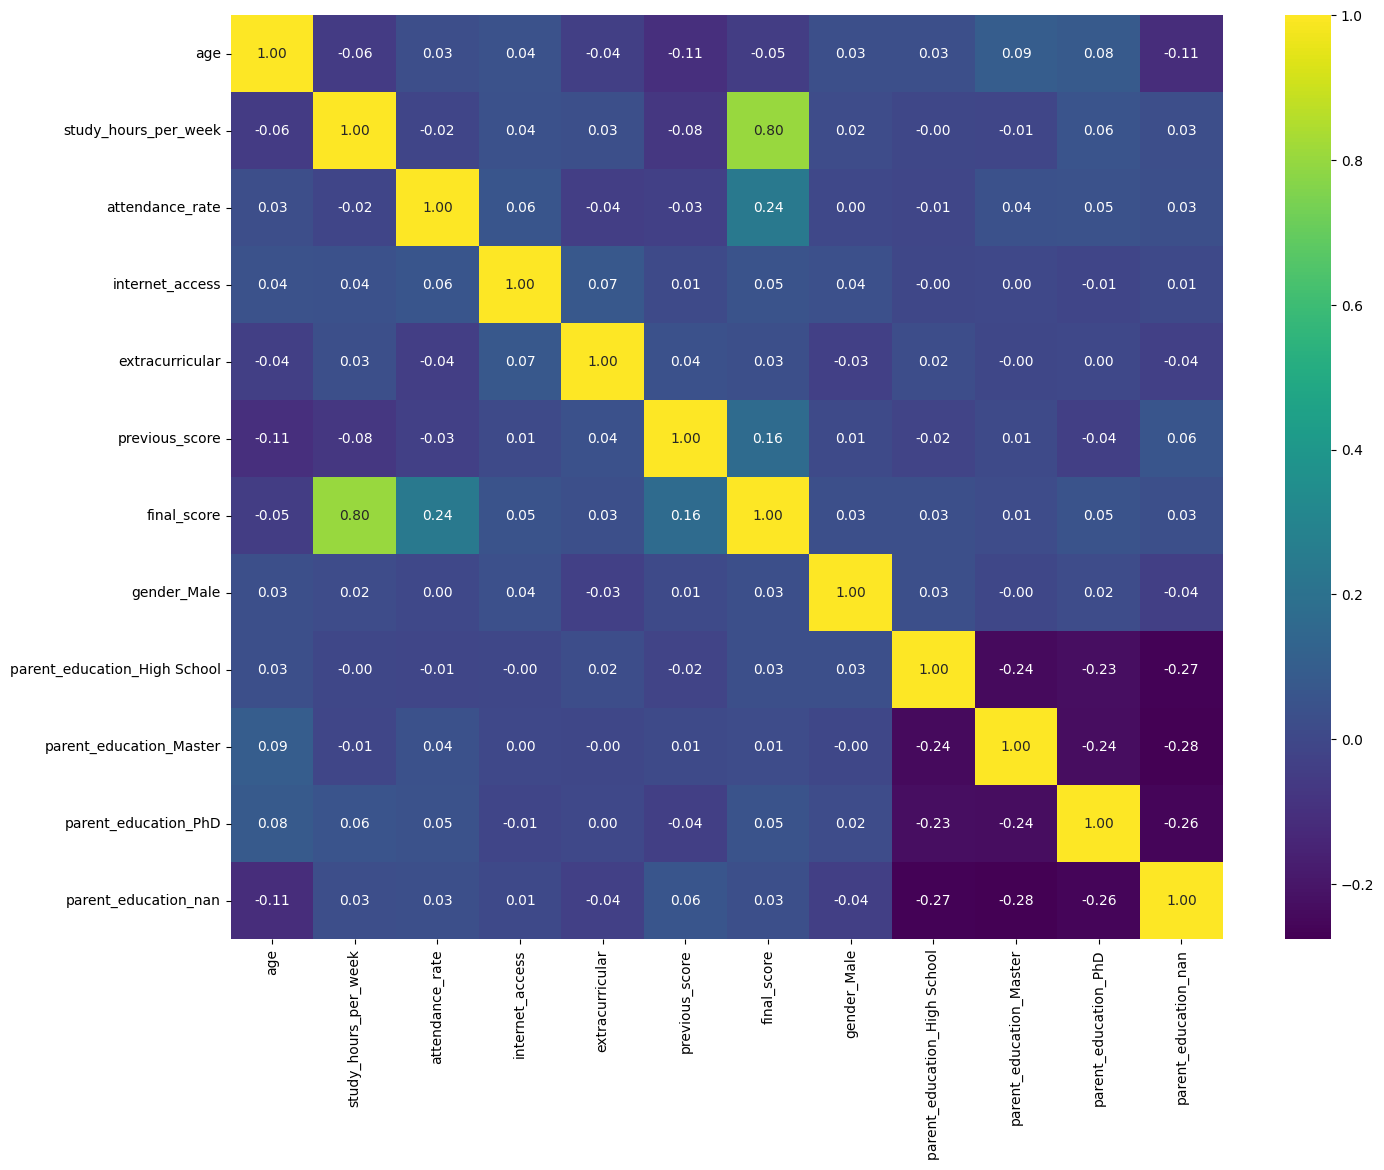

In [142]:
plt.figure(figsize=(16, 12))
sns.heatmap(performance_dummy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.show()

In [143]:
print(performance['final_score'].mean())
print(performance['final_score'].median())
print(performance['final_score'].std())

55.98
56.0
15.373753757921921


In [144]:
X = performance_dummy.drop(columns=['final_score'])
print('X columns: ', X.columns)

X = X.values
print('X shape: ', X.shape)

y = performance_dummy['final_score']
y = y.values.reshape(-1, 1)
print('y shape: ', y.shape)

X columns:  Index(['age', 'study_hours_per_week', 'attendance_rate', 'internet_access',
       'extracurricular', 'previous_score', 'gender_Male',
       'parent_education_High School', 'parent_education_Master',
       'parent_education_PhD', 'parent_education_nan'],
      dtype='str')
X shape:  (500, 11)
y shape:  (500, 1)


In [145]:
# DONE: Split into train/validation/test using a 70:15:15 ratio.
# Hint: first split off 30% as temporary data, then split that temporary data in half.

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5)

X_train, X_val, X_test = standardize_from_train(X_train, X_val, X_test)

## NumPy Regression Neural Network

Implement a fully connected neural network using NumPy.

Requirements:

- The number of hidden layers must be configurable.
- Every hidden layer must have the same number of neurons.
- Use sigmoid activation functions in hidden layers.
- Use a linear output layer.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support three update methods: batch gradient descent, stochastic gradient descent, and mini-batch gradient descent.
- Use early stopping to prevent overfitting.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `50` epochs.


In [146]:
def sigmoid_activation(z):
    # your code goes here
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
    x = sigmoid_activation(z)
    return x * (1 - x)

def soft_max(z):
    z_max = np.max(z, axis=1, keepdims=True)
    z_exp = np.exp(z - z_max) # estabilidade numérica
    return z_exp / np.sum(z_exp, axis=1, keepdims=True)

In [147]:
# If you want to implement without using POO, you can implement the following functions instead of the NeuralNetworkRegression class.
# My recommended approach is to implement the class, but you can implement the following functions if you prefer a functional programming style.
class NeuralNetworkRegression:
    def __init__(self, input_size, hidden_layers, neurons_per_layer, output_size=1):
        # DONE: initialize weights and biases for a variable number of layers.

        self.sizes = [input_size] + [neurons_per_layer for _ in range(hidden_layers)] + [output_size]
        self.Ws = [np.random.normal(0, np.sqrt(2 / (self.sizes[i] + self.sizes[i+1])), (self.sizes[i+1], self.sizes[i])) for i in range(hidden_layers + 1)]
        self.bs = [np.zeros((1, self.sizes[i+1])) for i in range(hidden_layers + 1)]

        self.hidd_layers = hidden_layers

    def forward(self, X, activation):
        # DONE: implement the forward pass.

        self.sums = []
        self.actv = [X]

        for i in range(self.hidd_layers):
            ai = self.actv[i] @ self.Ws[i].T
            ai_b = ai + self.bs[i]
            self.sums.append(ai_b)
            self.actv.append(activation(self.sums[i]))

        self.sums.append(self.actv[-1] @ self.Ws[-1].T + self.bs[-1])

    def backward(self, activation_dx, y_true, b_size, lr):
        # DONE: implement backpropagation.
        
        grad_Ws = []
        grad_bs = []

        delta = self.sums[-1] - y_true
        grad_Ws.append(lr * delta.T @ self.actv[-1] / b_size)
        grad_bs.append(lr * delta.sum(axis=0, keepdims=True) / b_size)

        for i in range(self.hidd_layers, 0, -1):
            delta = delta @ self.Ws[i] 
            delta *= activation_dx(self.sums[i-1])
            grad = delta.T @ self.actv[i-1]
            grad_Ws.append(lr * grad / b_size)
            grad_bs.append(lr * delta.sum(axis=0, keepdims=True) / b_size)

        for i in range(self.hidd_layers + 1):
            self.Ws[i] -= grad_Ws[self.hidd_layers - i]
            self.bs[i] -= grad_bs[self.hidd_layers - i]

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=50,
        learning_rate=0.01,
        update_method="mini_batch", # sgd => b_size = 1; mini => 1 < b_size < size x; full => b_size = size x
        batch_size=32,
        patience=10,
    ):
        # DONE: implement training with batch, SGD, and mini-batch updates.
        # DONE: implement early stopping and restore the best weights.
        # DONE: return training and validation loss histories.

        counter = 0
        best_w = [w.copy() for w in self.Ws]
        best_b = [b.copy() for b in self.bs]
        best_l = np.inf
        best_e = 1
        hist = []

        for e in range(epochs):
            # shuffling indices
            idx = np.random.permutation(X_train.shape[0])
            X_shuffled = X_train[idx]
            y_shuffled = y_train[idx]

            # slicing the training set for batches
            for start in range(0, X_shuffled.shape[0], batch_size):
                end = min(start + batch_size, X_shuffled.shape[0])
                self.forward(X_shuffled[start:end, :], sigmoid_activation)
                self.backward(sigmoid_derivative, y_shuffled[start:end, :], end-start, learning_rate)

            # tracking loss
            train_pred = self.predict(X_train)
            val_pred = self.predict(X_val)

            loss_t = rmse(y_train, train_pred)
            loss_v = rmse(y_val, val_pred)

            hist.append({'dataset':'training','loss':loss_t,'epoch':e})
            hist.append({'dataset':'validation','loss':loss_v,'epoch':e})

            # early stopping
            if loss_v < best_l:
                counter = 0
                best_w = [w.copy() for w in self.Ws]
                best_b = [b.copy() for b in self.bs]
                best_l = loss_v
                best_e = e + 1 # e starts at 0
            elif counter < patience:
                counter += 1
            else:
                self.Ws = [w.copy() for w in best_w]
                self.bs = [b.copy() for b in best_b]
                return best_e, hist
            
        return best_e, hist

    def predict(self, X):
        # DONE: return predictions from the network.
        Xp = X if len(X.shape) > 1 else X.reshape(1, -1)

        self.forward(Xp, sigmoid_activation)
        return self.sums[-1] 


## Regression Hyperparameter Tuning

Choose:

- 3 values for number of hidden layers, for example `[1, 2, 3]`.
- 3 values for neurons per hidden layer, for example `[100, 150, 250]`.
- The 3 update methods: batch GD, SGD, and mini-batch GD.

For each combination, train the model and record the validation RMSE. This gives 27 validation results.


In [148]:
print(X_train.mean())
print(X_train.std())
print(y_train.mean())
print(y_train.std())

3.1928283970518785e-16
0.9999999999999998
55.88857142857143
15.23629635215239


In [150]:
regression_hidden_layers = [1, 2, 3]
regression_neurons = [100, 150, 250]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_update_sizes = [X_train.shape[0], 1, 32]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

# Done: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.

# regression_results = pd.DataFrame(...)
# display(regression_results.sort_values("validation_rmse"))

grid_search = []

for i in range(3):
    for j in range(3):
        for k in range(3):
            nw = NeuralNetworkRegression(X_train.shape[1], 
                                        regression_hidden_layers[i], 
                                        regression_neurons[j])
            
            best_e, _ = nw.fit(X_train, y_train, X_val, y_val, regression_epochs, regression_learning_rate,
                regression_update_methods[k], regression_update_sizes[k], regression_patience)
            
            val_loss = rmse(y_val, nw.predict(X_val))
            grid_search.append({'update_method':regression_update_methods[k], 
                                'batch_size':regression_update_sizes[k],
                              'hidden_layers':regression_hidden_layers[i], 
                              'neurons_per_layer':regression_neurons[j], 
                              'validation_rmse': val_loss, 
                              'best_epoch':best_e, 
                              'stopped_epoch':min(best_e+regression_patience, regression_epochs)})

regression_results = pd.DataFrame(grid_search)
display(regression_results.sort_values('validation_rmse'))


,update_method,batch_size,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
14,mini_batch,32,2,150,7.016071,20,30
11,mini_batch,32,2,100,7.074623,28,38
17,mini_batch,32,2,250,7.102427,23,33
23,mini_batch,32,3,150,7.123817,31,41
20,mini_batch,32,3,100,7.159304,48,50
5,mini_batch,32,1,150,7.205341,28,38
26,mini_batch,32,3,250,7.208276,30,40
16,sgd,1,2,250,7.212690,12,22
2,mini_batch,32,1,100,7.217066,9,19
10,sgd,1,2,100,7.235061,5,15


update_method        mini_batch
batch_size                   32
hidden_layers                 2
neurons_per_layer           150
validation_rmse        7.016071
best_epoch                   20
stopped_epoch                30
Name: 14, dtype: object

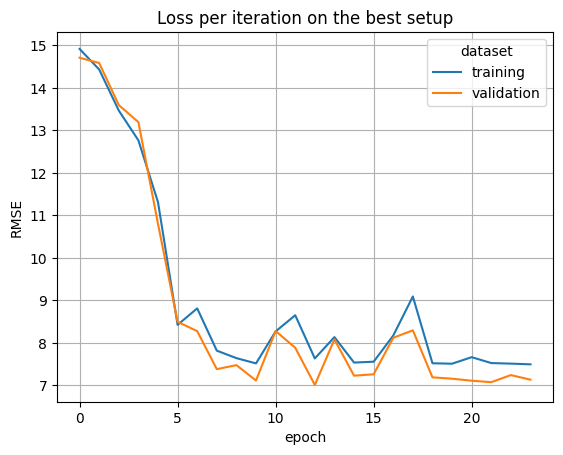

In [151]:
# Done: Plot training and validation loss curves for the selected/best model.
best_setup = regression_results.loc[regression_results['validation_rmse'].idxmin()]
display(best_setup)

nw = NeuralNetworkRegression(X_train.shape[1], best_setup['hidden_layers'], best_setup['neurons_per_layer'])
e, h = nw.fit(X_train, y_train, X_val, y_val, regression_epochs, regression_learning_rate, best_setup['update_method'], best_setup['batch_size'])

hdf = pd.DataFrame(h)
sns.lineplot(hdf, x='epoch', y='loss', hue='dataset')
plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.title('Loss per iteration on the best setup')
plt.grid(True)

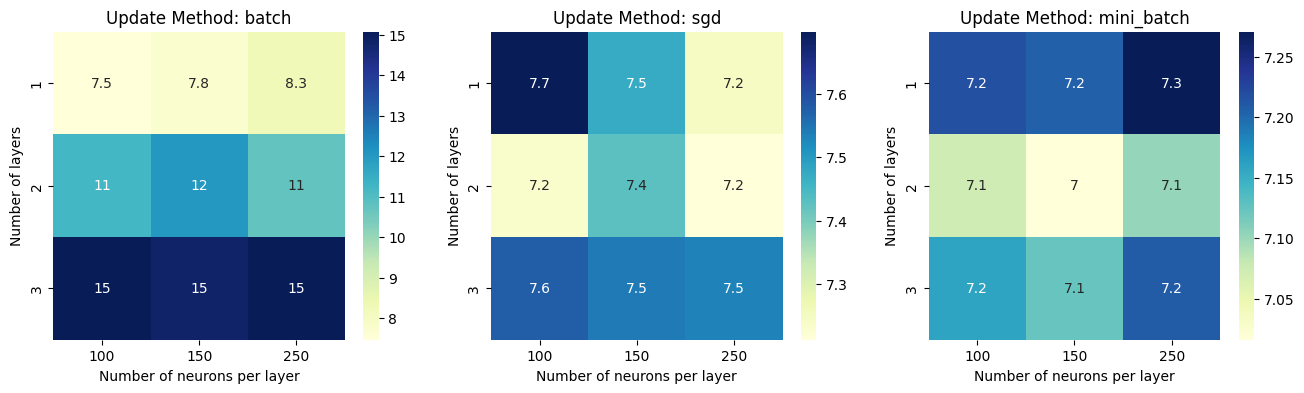

In [152]:
# Done: Produce one validation RMSE heatmap per update method.
# Rows: number of hidden layers.
# Columns: neurons per hidden layer.
# Values: validation RMSE.

vmin = regression_results['validation_rmse'].min()
vmax = regression_results['validation_rmse'].max()
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    tabela = regression_results[regression_results['update_method'] == regression_update_methods[i]].pivot_table(index='hidden_layers', columns='neurons_per_layer', values='validation_rmse')
    sns.heatmap(tabela, annot=True, cmap="YlGnBu", ax=axs[i])
    axs[i].set_ylabel('Number of layers')
    axs[i].set_xlabel('Number of neurons per layer')
    axs[i].set_title('Update Method: ' + regression_update_methods[i])
plt.show()

Test RMSE:  11.660654985034691


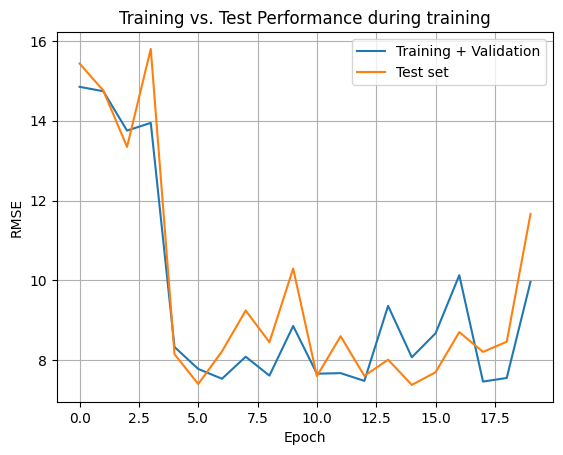

In [153]:
# Done: Select the final NumPy regression model using validation RMSE only.
# Then evaluate that selected model on the test set with RMSE.

# Expected variable names for the TensorFlow baseline cell:
# best_hidden_layers = ...
# best_neurons = ...
# best_regression_test_rmse = ...
# best_regression_validation_rmse = ...

# best_setup is selected with the best validation rmse
best_hidden_layers = best_setup['hidden_layers']
best_neurons = best_setup['neurons_per_layer']
best_batch_size = best_setup['batch_size']
best_update_method = best_setup['update_method']
best_epoch = best_setup['best_epoch']
best_regression_validation_rmse = best_setup['validation_rmse']

# given the optimal hyperparameters, training with both training and validation dataset
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.vstack((y_train, y_val))

nw = NeuralNetworkRegression(X_train_val.shape[1], 
                             best_hidden_layers,
                             best_neurons)

e, h = nw.fit(X_train_val, y_train_val, X_test, y_test, epochs=best_epoch,
              learning_rate=regression_learning_rate, update_method=best_update_method,
              batch_size=best_batch_size, patience=regression_epochs) # hig patience so that it doesnt do anything

nw_test_rmse = rmse(y_test, nw.predict(X_test))
hist_df = pd.DataFrame(h)

print('Test RMSE: ', nw_test_rmse)
sns.lineplot(hist_df[hist_df['dataset'] == 'training'], x='epoch', y='loss', label='Training + Validation')
sns.lineplot(hist_df[hist_df['dataset'] == 'validation'], x='epoch', y='loss', label='Test set')
plt.ylabel('RMSE')
plt.xlabel('Epoch')
plt.title('Training vs. Test Performance during training')
plt.grid(True)
plt.show()

## Scratch Linear Regression Baseline

Use your own linear regression implementation from previous labs or courseworks. Train it on the same training set and evaluate it on the same test set.


In [154]:
class ScratchLinearRegression:
    def fit(self, X, y, epochs=5000, learning_rate=0.01, early_stop=False, X_val=None, y_val=None, patience=100):
        # Done: paste/adapt your previous linear regression implementation.

        n_datapoints = X.shape[0]
        X_bias = np.hstack((np.ones((n_datapoints, 1)), X))
        np_y = y if len(y.shape) > 1 else y.reshape(-1, 1)

        self.w = np.random.normal(loc=0, scale=1, size=(1, X_bias.shape[1]))
        self.hist = []
        self.best_e = epochs

        if early_stop and X_val is not None and y_val is not None:
            counter = 0;
            best_w = self.w.copy()
            best_l = np.inf
            self.best_e = 1
        else:
            print('No ES')
            early_stop = False
        
        for e in range(epochs):
            grad = np.zeros(X_bias.shape[1])
            for lin, target in zip(X_bias, np_y):
                grad = (self.w @ lin - target) * lin
                self.w -= learning_rate * (grad / n_datapoints)

            loss_t = rmse(y, self.predict(X))
            self.hist.append({'epoch':e, 'loss':loss_t, 'dataset':'training'})

            if early_stop:
                loss_v = rmse(y_val, self.predict(X_val))
                self.hist.append({'epoch':e, 'loss':loss_v, 'dataset':'validation'})

                if loss_v < best_l:
                    best_w = self.w.copy()
                    counter = 0
                    self.best_e = e + 1
                elif counter < patience:
                    counter += 1
                else:
                    self.w = best_w.copy()
                    return

    def predict(self, X):
        # Done: return predictions.
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        return X @ self.w.T


Baseline Validation RMSE:  7.359238768842824


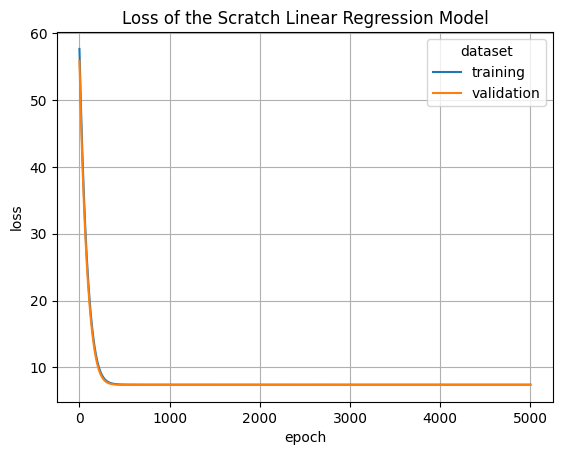

In [155]:
# Done: train and evaluate your scratch linear regression baseline.

slr = ScratchLinearRegression()
slr.fit(X_train, y_train, early_stop=True, X_val=X_val, y_val=y_val, patience=10)
slr_val_rmse = rmse(y_val, slr.predict(X_val))
slr_best_e = slr.best_e

print('Baseline Validation RMSE: ', slr_val_rmse)
sns.lineplot(pd.DataFrame(slr.hist), x='epoch', y='loss', hue='dataset')
plt.title('Loss of the Scratch Linear Regression Model')
plt.grid(True)
plt.show()

In [156]:
slr_test = ScratchLinearRegression()
slr_test.fit(X_train_val, y_train_val, epochs=slr.best_e)
slr_test_rmse = rmse(y_test, slr_test.predict(X_test))
print(slr_test_rmse)

No ES
7.665680677148638


## TensorFlow Regression Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `best_hidden_layers`, and `best_neurons`.


In [157]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_hidden_layers" not in globals() or "best_neurons" not in globals():
    raise NameError("Define best_hidden_layers and best_neurons from your validation search before running this cell.")

regression_patience = globals().get("regression_patience", 10)
regression_epochs = globals().get("regression_epochs", 50)
regression_learning_rate = globals().get("regression_learning_rate", 0.01)

tf_regression_model = tf.keras.Sequential()
tf_regression_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for _ in range(int(best_hidden_layers)):
    tf_regression_model.add(tf.keras.layers.Dense(int(best_neurons), activation="sigmoid"))
tf_regression_model.add(tf.keras.layers.Dense(1, activation="linear"))

tf_regression_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=regression_learning_rate),
    loss="mse",
)

tf_regression_history = tf_regression_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=regression_epochs,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=regression_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_regression_val_predictions = tf_regression_model.predict(X_val, verbose=0)
tf_regression_test_predictions = tf_regression_model.predict(X_test, verbose=0)

tf_regression_results = pd.DataFrame([
    {
        "model": "TensorFlow regression baseline",
        "hidden_layers": int(best_hidden_layers),
        "neurons_per_layer": int(best_neurons),
        "validation_rmse": float(np.sqrt(np.mean((y_val - tf_regression_val_predictions) ** 2))),
        "test_rmse": float(np.sqrt(np.mean((y_test - tf_regression_test_predictions) ** 2))),
        "epochs_trained": len(tf_regression_history.history["loss"]),
    }
])

display(tf_regression_results)


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Done: Build the final regression comparison table.
# Include at least:
# - your NumPy NN
# - your scratch linear regression
# - the TensorFlow baseline above

tfr = tf_regression_results.iloc[0]
model_results = []
model_results.append({'model':tfr.model,
                      'hidden_layers':tfr.hidden_layers,
                      'neurons_per_layer':tfr.neurons_per_layer,
                      'validation_rmse':tfr.validation_rmse, 
                      'test_rmse': tfr.test_rmse,
                      'epochs_trained': tfr.epochs_trained})

model_results.append({'model':'Scratch Linear Regression',
                      'hidden_layers':0,
                      'neurons_per_layer':'N/A',
                      'validation_rmse':slr_val_rmse, 
                      'test_rmse': slr_test_rmse,
                      'epochs_trained': slr.best_e})

model_results.append({'model':'Numpy Neural Network : ' + best_update_method,
                      'hidden_layers': best_hidden_layers,
                      'neurons_per_layer': best_neurons,
                      'validation_rmse': best_regression_validation_rmse, 
                      'test_rmse': nw_test_rmse,
                      'epochs_trained': best_epoch})

df_model_results = pd.DataFrame(model_results)
display(df_model_results)


,model,hidden_layers,neurons_per_layer,validation_rmse,test_rmse,epochs_trained
0,TensorFlow regression baseline,1,250,10.278857,9.333874,13
1,Scratch Linear Regression,0,N/A,8.633813,7.150290,5000
2,Numpy Neural Network : sgd,1,250,8.287724,8.169983,16


# Part 2 - Multiclass Classification With Neural Networks (50%)

## Dataset

Use `dry_bean_database.csv`. Each row is one bean described by 16 numerical features. The target column is `Class`, with 7 mutually exclusive classes.

Required preprocessing:

1. Load the dataset.
2. Remove duplicated rows.
3. Convert numeric feature columns when needed. Some copies may store decimal values as strings with comma separators.
4. Encode `Class` as a multiclass target.
5. Split into training, validation, and test sets using a 70:15:15 ratio. Use stratification.
6. Standardize features manually using only training-set statistics.


In [ ]:
dry_beans = pd.read_csv("../../dry_bean_database.csv", decimal=",")
display(dry_beans.head())
display(dry_beans.describe(include="all"))


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DERMASON
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3546
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063,NaN
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366,NaN
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,NaN
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703,NaN
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386,NaN
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883,NaN


In [ ]:
# Done: Classification preprocessing.
# - Drop duplicate rows.
# - Convert all feature columns to float.
# - Encode Class as integers and one-hot vectors.

# Expected variable names:
# class_names = [...]
# X = ...
# class_labels = ...
# y = ...  # one-hot encoded target

display(dry_beans.dtypes)
dry_beans['Area'] = pd.to_numeric(dry_beans['Area'], errors='coerce').astype(float)
dry_beans['ConvexArea'] = pd.to_numeric(dry_beans['ConvexArea'], errors='coerce').astype(float)
display(dry_beans.dtypes)

display(dry_beans.isna().astype(int).sum())
display(dry_beans.duplicated().astype(int).sum())

class_names = dry_beans['Class'].unique()
display(class_names)

dry_beans_drop = dry_beans.dropna()
dry_beans_drop = dry_beans_drop.drop_duplicates()


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Area               float64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea         float64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

np.int64(68)

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

In [ ]:
X = dry_beans_drop.drop(columns=['Class'])
print ('Features: ', X.columns)
print('X Shape: ', X.shape)
display(X.head())

X = X.values

y = pd.get_dummies(dry_beans_drop['Class'], columns=['Class'], dtype=int)
print('Classes: ', y.columns)
print('y shape: ', y.shape)
display(y.head())
y = y.values

Features:  Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')
X Shape:  (13543, 16)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


Classes:  Index(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'], dtype='str')
y shape:  (13543, 7)


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [ ]:
# Done: Split into train/validation/test using a 70:15:15 ratio with stratification.
# Done: Standardize X_train, X_val, and X_test using only training-set statistics.

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test
# labels_train, labels_val, labels_test

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5, stratify=y_aux)

X_train, X_val, X_test = standardize_from_train(X_train, X_val, X_test)

## NumPy Multiclass Neural Network

Implement a fully connected multiclass classifier using NumPy.

Requirements:

- The architecture must accept a list of hidden-layer sizes, for example `[64, 128, 256]`.
- Use sigmoid activation functions in hidden layers.
- Use softmax in the output layer.
- Use multiclass cross-entropy loss.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support batch GD, SGD, and mini-batch GD.
- Use early stopping.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `1000` epochs.


In [ ]:
def soft_max(z):
    z_max = np.max(z, axis=1, keepdims=True)
    z_exp = np.exp(z - z_max) # estabilidade numérica
    return z_exp / np.sum(z_exp, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    y_clip = np.clip(y_pred, 1e-8, 1)
    loss = y_true * np.log(y_clip)
    loss = np.sum(loss, axis=1)
    return (-1) * np.mean(loss)

class NeuralNetworkMulticlassClassifier:
    def __init__(self, input_size, hidden_layers, output_size, hdd_act=sigmoid_activation, 
                 hdd_act_dx=sigmoid_derivative, out_act=soft_max, out_act_dx=(lambda x: np.ones_like(x))):
        # Done: initialize weights and biases for the architecture list.
        self.hidd_size = len(hidden_layers)

        self.sizes = [input_size] + hidden_layers + [output_size]
        self.Ws = [np.random.normal(0, np.sqrt(2 / (self.sizes[i] + self.sizes[i+1])), (self.sizes[i+1], self.sizes[i])) for i in range(self.hidd_size + 1)]
        self.bs = [np.zeros((1, self.sizes[i+1])) for i in range(self.hidd_size + 1)]

        self.hdd_act = hdd_act
        self.hdd_act_dx = hdd_act_dx
        self.out_act = out_act
        self.out_act_dx = out_act_dx

    def forward(self, X):
        # Done: implement sigmoid hidden layers and softmax output.

        self.sums = []
        self.actv = [X]

        for i in range(self.hidd_size):
            ai = self.actv[i] @ self.Ws[i].T
            ai_b = ai + self.bs[i]
            self.sums.append(ai_b)
            self.actv.append(self.hdd_act(self.sums[i]))

        self.sums.append(self.actv[-1] @ self.Ws[-1].T + self.bs[-1])
        self.actv.append(self.out_act(self.sums[-1]))

    def backward(self, y_true, b_size, lr):
        # Done: implement backpropagation for softmax + cross-entropy.
        
        grad_Ws = []
        grad_bs = []

        delta = (self.actv[-1] - y_true) * self.out_act_dx(self.sums[-1])
        grad_Ws.append(lr * delta.T @ self.actv[-2] / b_size)
        grad_bs.append(lr * delta.sum(axis=0, keepdims=True) / b_size)

        for i in range(self.hidd_size, 0, -1):
            delta = delta @ self.Ws[i] 
            delta *= self.hdd_act_dx(self.sums[i-1])
            grad = delta.T @ self.actv[i-1]
            grad_Ws.append(lr * grad / b_size)
            grad_bs.append(lr * delta.sum(axis=0, keepdims=True) / b_size)

        for i in range(self.hidd_size + 1):
            self.Ws[i] -= grad_Ws[self.hidd_size - i]
            self.bs[i] -= grad_bs[self.hidd_size - i]

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=1000,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=256,
        patience=50,
    ):
        # Done: implement training with batch, SGD, and mini-batch updates.
        # Done: implement early stopping and restore the best weights.

        counter = 0
        best_w = [w.copy() for w in self.Ws]
        best_b = [b.copy() for b in self.bs]
        best_l = np.inf
        best_e = 1
        hist = []

        for e in range(epochs):
            # shuffling indices
            idx = np.random.permutation(X_train.shape[0])
            X_shuffled = X_train[idx]
            y_shuffled = y_train[idx]

            # slicing the training set for batches
            for start in range(0, X_shuffled.shape[0], batch_size):
                end = min(start + batch_size, X_shuffled.shape[0])
                self.forward(X_shuffled[start:end, :])
                self.backward(y_shuffled[start:end, :], end-start, learning_rate)

            # tracking loss
            train_pred = self.predict_proba(X_train)
            val_pred = self.predict_proba(X_val)

            loss_t = cross_entropy(y_train, train_pred)
            loss_v = cross_entropy(y_val, val_pred)

            hist.append({'dataset':'training','loss':loss_t,'epoch':e})
            hist.append({'dataset':'validation','loss':loss_v,'epoch':e})

            # early stopping
            if loss_v < best_l:
                counter = 0
                best_w = [w.copy() for w in self.Ws]
                best_b = [b.copy() for b in self.bs]
                best_l = loss_v
                best_e = e + 1 # e starts at 0
            elif counter < patience:
                counter += 1
            else:
                self.Ws = [w.copy() for w in best_w]
                self.bs = [b.copy() for b in best_b]
                return best_e, hist
            
        return best_e, hist

    def predict_proba(self, X):
        # Done: return class probabilities.
        self.forward(X)
        return self.actv[-1]

    def predict(self, X):
        # Done: return predicted class indices.
        self.forward(X)
        return self.actv[-1].argmax(axis=1)


## Classification Hyperparameter Tuning

Choose 3 hidden-layer configurations. The number of neurons does not need to be the same in every layer for this part.

For each update method, train the 3 architectures and record the validation loss. This gives 9 validation results.


In [ ]:
classification_layer_configs = [
    [64],
    [128, 64],
    [128, 128, 64],
]
classification_update_methods = ["batch", "sgd", "mini_batch"]
classification_update_sizes = [X_train.shape[0], 1, 32]
classification_learning_rate = 0.01
classification_epochs = 1000
classification_patience = 50

# Done: train every architecture/update-method combination.
# Store at least: update_method, architecture, validation_loss, best_epoch, stopped_epoch.

# classification_results = pd.DataFrame(...)
# display(classification_results.sort_values("validation_loss"))

grid_search = []

for i in range(3):
    for j in range(3):
        nw = NeuralNetworkMulticlassClassifier(X_train.shape[1], classification_layer_configs[i], y_train.shape[1], sigmoid_activation, 
                                               sigmoid_derivative, soft_max)
        
        e, h = nw.fit(X_train, y_train, X_val, y_val, batch_size=classification_update_sizes[j])
        
        val_loss = cross_entropy(y_val, nw.predict_proba(X_val))
        grid_search.append({'update_method':classification_update_methods[j], 
                            'batch_size':classification_update_sizes[j],
                            'architecture':classification_layer_configs[i], 
                            'validation_loss': val_loss, 
                            'best_epoch':e, 
                            'stopped_epoch':min(e+classification_patience, classification_epochs)})
        
        print(f'Architecture: {classification_layer_configs[i]} | Loss: {val_loss}')
        
classification_results = pd.DataFrame(grid_search)
display(classification_results.sort_values('validation_loss'))

# Aparentemente, batches maiores não convergem em tempo 1000 iterações

Architecture: [64] | Loss: 0.869243423783733
Architecture: [64] | Loss: 0.16438284022799673
Architecture: [64] | Loss: 0.17941650253506794
Architecture: [128, 64] | Loss: 1.450019240334497
Architecture: [128, 64] | Loss: 0.1649963594462036
Architecture: [128, 64] | Loss: 0.17665993056826645
Architecture: [128, 128, 64] | Loss: 1.829989464654273
Architecture: [128, 128, 64] | Loss: 0.17162727770910358
Architecture: [128, 128, 64] | Loss: 0.18205302188361136


,update_method,batch_size,architecture,validation_loss,best_epoch,stopped_epoch
1,sgd,1,[64],0.164383,205,1000
4,sgd,1,"[128, 64]",0.164996,207,1000
7,sgd,1,"[128, 128, 64]",0.171627,71,1000
5,mini_batch,32,"[128, 64]",0.176660,989,1000
2,mini_batch,32,[64],0.179417,994,1000
8,mini_batch,32,"[128, 128, 64]",0.182053,994,1000
0,batch,9480,[64],0.869243,1000,1000
3,batch,9480,"[128, 64]",1.450019,1000,1000
6,batch,9480,"[128, 128, 64]",1.829989,1000,1000


update_method           sgd
batch_size                1
architecture           [64]
validation_loss    0.164383
best_epoch              205
stopped_epoch          1000
Name: 1, dtype: object

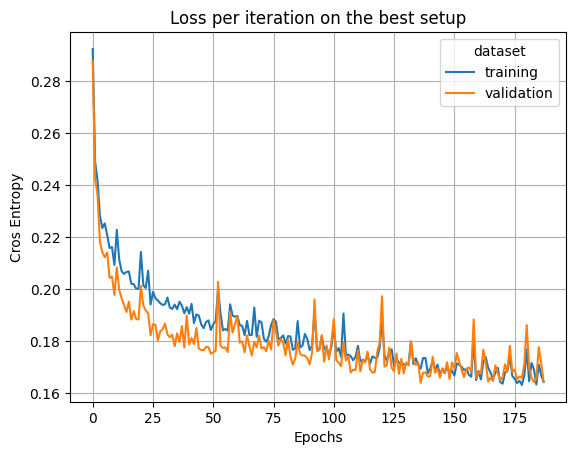

In [ ]:
# Done: Plot training and validation loss curves for the selected/best classifier.

best_setup = classification_results.loc[classification_results['validation_loss'].idxmin()]
display(best_setup)

nw = NeuralNetworkMulticlassClassifier(X_train.shape[1], best_setup['architecture'],  y_train.shape[1], 
                                       sigmoid_activation, sigmoid_derivative, soft_max)
e, h = nw.fit(X_train, y_train, X_val, y_val, classification_epochs, classification_learning_rate, best_setup['update_method'], best_setup['batch_size'])

hdf = pd.DataFrame(h)
sns.lineplot(hdf, x='epoch', y='loss', hue='dataset')
plt.ylabel('Cros Entropy')
plt.xlabel('Epochs')
plt.title('Loss per iteration on the best setup')
plt.grid(True)


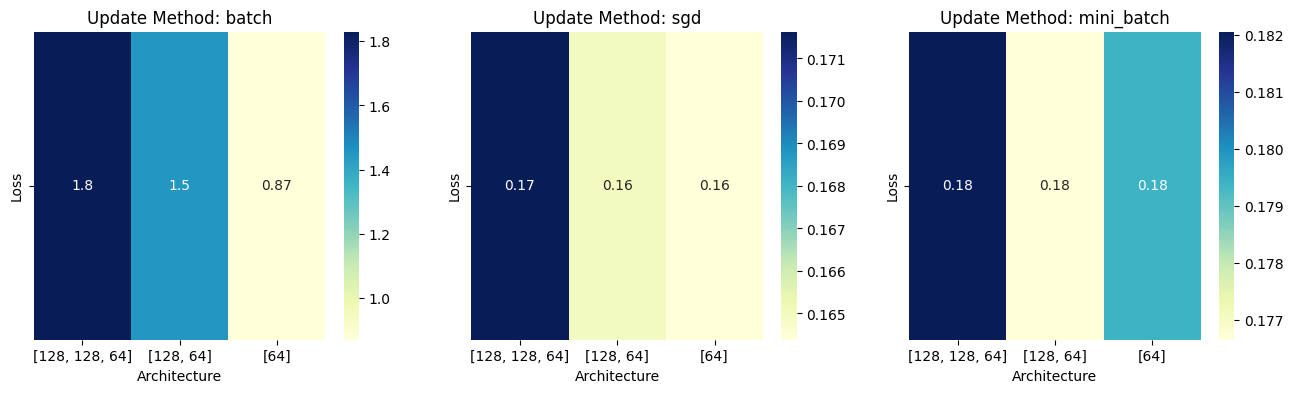

In [ ]:
# TODO: Produce one validation-loss heatmap per update method.
# Use architecture labels on the columns.

vmin = classification_results['validation_loss'].min()
vmax = classification_results['validation_loss'].max()
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    method_data = classification_results[classification_results['update_method'] == classification_update_methods[i]]
    method_data['architecture'] = method_data['architecture'].astype('string')
    medias_arq = method_data.groupby('architecture')['validation_loss'].mean().to_dict()
    tabela = pd.DataFrame([medias_arq], index=['Loss'])
    sns.heatmap(tabela, annot=True, cmap="YlGnBu", ax=axs[i])
    axs[i].set_ylabel('')
    axs[i].set_xlabel('Architecture')
    axs[i].set_title('Update Method: ' + classification_update_methods[i])
plt.show()


Test Loss:  0.191898246835699


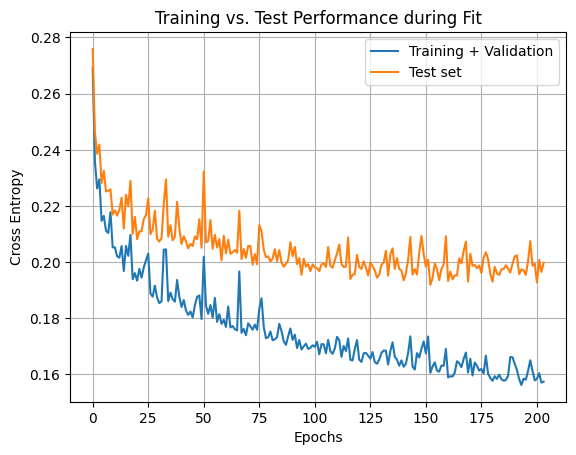

In [ ]:
# Done: Select the final NumPy classifier using validation loss only.
# Then evaluate it on the test set with AUROC, precision, F1, and accuracy.

# Expected variable name for the TensorFlow baseline cell:
# best_classification_layers = ...

best_classification_layers = best_setup['architecture']
best_batch_size = best_setup['batch_size']
best_update_method = best_setup['update_method']
best_epoch = best_setup['best_epoch']
best_validation_rmse = best_setup['validation_loss']

X_train_val = np.vstack((X_train, X_val))
y_train_val = np.vstack((y_train, y_val))

nw = NeuralNetworkMulticlassClassifier(X_train_val.shape[1], best_setup['architecture'],  y_train_val.shape[1], 
                                       sigmoid_activation, sigmoid_derivative, soft_max)
e, h = nw.fit(X_train_val, y_train_val, X_test, y_test, best_epoch, classification_learning_rate, best_setup['update_method'], best_setup['batch_size'])

nw_proba = nw.predict_proba(X_test)
nw_test_loss = cross_entropy(y_test, nw_proba)
hist_df = pd.DataFrame(h)

print('Test Loss: ', nw_test_loss)
sns.lineplot(hist_df[hist_df['dataset'] == 'training'], x='epoch', y='loss', label='Training + Validation')
sns.lineplot(hist_df[hist_df['dataset'] == 'validation'], x='epoch', y='loss', label='Test set')
plt.ylabel('Cross Entropy')
plt.xlabel('Epochs')
plt.title('Training vs. Test Performance during Fit')
plt.grid(True)
plt.show()

## Scratch Logistic Regression Baseline

Use your own logistic regression implementation from previous labs or courseworks. For this multiclass dataset, you may implement one-vs-rest logistic regression or softmax regression.


In [ ]:
class ScratchLogisticRegression:
    def fit(self, X, y, epochs=1000, learning_rate=0.01, early_stop=False, patience=100, X_val=None, y_val=None):
        # Done: paste/adapt your previous logistic regression implementation.
        n_datapoints = X.shape[0]
        ones = np.ones(n_datapoints)
        phi = np.column_stack((ones, X))
        self.w = np.random.normal(0, 1, (y.shape[1], phi.shape[1])) * 1e-1
        self.hist = []
        self.best_e = epochs

        if early_stop and X_val is not None and y_val is not None:
            counter = 0;
            best_w = self.w.copy()
            best_l = np.inf
            self.best_e = 1
        else:
            print('No ES')
            early_stop = False

        for e in range(epochs):
            y_pred = soft_max(phi @ self.w.T)
            grad = (y_pred - y).T @ phi / n_datapoints
            self.w -= learning_rate * grad

            loss_t = cross_entropy(y, self.predict_proba(X))
            self.hist.append({'epoch':e, 'loss':loss_t, 'dataset':'training'})

            if early_stop:
                loss_v = cross_entropy(y_val, self.predict_proba(X_val))
                self.hist.append({'epoch':e, 'loss':loss_v, 'dataset':'validation'})

                if loss_v < best_l:
                    best_w = self.w.copy()
                    counter = 0
                    self.best_e = e + 1
                elif counter < patience:
                    counter += 1
                else:
                    self.w = best_w.copy()
                    return

    def predict_proba(self, X):
        # Done: return class probabilities.
        Xp = np.hstack((np.ones((X.shape[0], 1)), X))
        return soft_max(Xp @ self.w.T)

    def predict(self, X):
        # Done: return predicted class indices.
        proba = self.predict_proba(X)
        return proba.argmax(axis=1)


Baseline Validation Loss:  0.5701551248463389


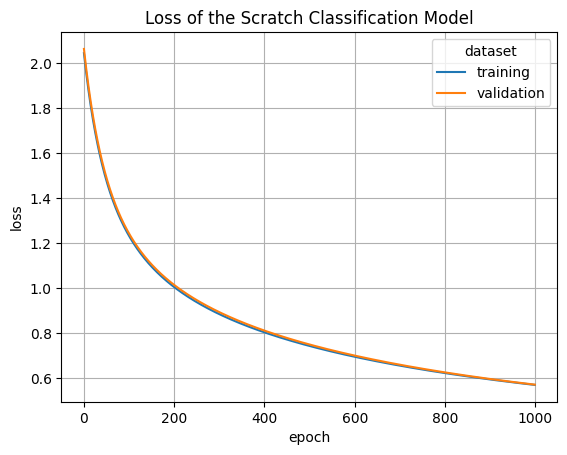

In [ ]:
# Done: train and evaluate your scratch classification baseline.

slr = ScratchLogisticRegression()
slr.fit(X_train, y_train, early_stop=True, X_val=X_val, y_val=y_val, patience=10)
slr_val_loss = cross_entropy(y_val, slr.predict_proba(X_val))
slr_best_e = slr.best_e

print('Baseline Validation Loss: ', slr_val_loss)
sns.lineplot(pd.DataFrame(slr.hist), x='epoch', y='loss', hue='dataset')
plt.title('Loss of the Scratch Classification Model')
plt.grid(True)
plt.show()

In [ ]:
slr_test = ScratchLogisticRegression()
slr_test.fit(X_train_val, y_train_val, epochs=slr.best_e)
slr_proba = slr_test.predict_proba(X_test)
slr_test_loss = cross_entropy(y_test, slr_proba)
print(slr_test_loss)

No ES
0.5613992434318187


## TensorFlow Classification Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `class_names`, and `best_classification_layers`.


In [ ]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_classification_layers" not in globals():
    raise NameError("Define best_classification_layers from your validation search before running this cell.")

classification_patience = globals().get("classification_patience", 50)
classification_epochs = globals().get("classification_epochs", 1000)
classification_learning_rate = globals().get("classification_learning_rate", 0.01)

tf_classification_model = tf.keras.Sequential()
tf_classification_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for units in best_classification_layers:
    tf_classification_model.add(tf.keras.layers.Dense(int(units), activation="sigmoid"))
tf_classification_model.add(tf.keras.layers.Dense(y_train.shape[1], activation="softmax"))

tf_classification_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=classification_learning_rate),
    loss="categorical_crossentropy",
)

tf_classification_history = tf_classification_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=classification_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_classification_probabilities = tf_classification_model.predict(X_test, verbose=0)
tf_classification_predictions = np.argmax(tf_classification_probabilities, axis=1)
tf_true_labels = np.argmax(y_test, axis=1)

tf_precision, tf_recall, tf_f1, _ = precision_recall_fscore_support(
    tf_true_labels,
    tf_classification_predictions,
    average="macro",
    zero_division=0,
)

tf_classification_results = pd.DataFrame([
    {
        "model": "TensorFlow classification baseline",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": roc_auc_score(y_test, tf_classification_probabilities, average="macro"),
        "test_accuracy": accuracy_score(tf_true_labels, tf_classification_predictions),
        "test_macro_precision": tf_precision,
        "test_macro_recall": tf_recall,
        "test_macro_f1": tf_f1,
        "epochs_trained": len(tf_classification_history.history["loss"]),
    }
])

display(tf_classification_results)


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,TensorFlow classification baseline,[64],0.994207,0.926181,0.935929,0.938053,0.936857,1000


In [ ]:
# TODO: Build the final classification comparison table and barplots.
# Include at least:
# - your NumPy NN
# - your scratch logistic regression
# - the TensorFlow baseline above

tfc = tf_classification_results.iloc[0]
model_results = []
model_results.append({'model':tfc.model,
                      'architecture':tfc.architecture,
                      'test_macro_ovr_auroc': tfc.test_macro_ovr_auroc,
                      'test_accuracy':tfc.test_accuracy, 
                      'test_macro_precision': tfc.test_macro_precision,
                      'test_macro_recall':tfc.test_macro_recall,
                      'test_macro_f1':tfc.test_macro_f1,
                      'epochs_trained': tfc.epochs_trained})

slr_pred = slr.predict(X_test)
slr_precision, slr_recall, slr_f1, _ = precision_recall_fscore_support(y_test.argmax(axis=1), slr_pred, average="macro", zero_division=0)

model_results.append({'model':'Scratch Logistic Regression',
                      'architecture':'N/A',
                      "test_macro_ovr_auroc": roc_auc_score(y_test, slr_proba, average="macro"),
                      "test_accuracy": accuracy_score(tf_true_labels, slr_pred),
                      "test_macro_precision": slr_precision,
                      "test_macro_recall": slr_recall,
                      "test_macro_f1": slr_f1,
                      "epochs_trained": slr.best_e})

nw_pred = nw.predict(X_test)
nw_precision, nw_recall, nw_f1, _ = precision_recall_fscore_support(y_test.argmax(axis=1), nw_pred, average="macro", zero_division=0)

model_results.append({'model':'Numpy Neural Network : ' + best_update_method,
                      'architecture':best_hidden_layers,
                      "test_macro_ovr_auroc": roc_auc_score(y_test, nw_proba, average="macro"),
                      "test_accuracy": accuracy_score(tf_true_labels, nw_pred),
                      "test_macro_precision": nw_precision,
                      "test_macro_recall": nw_recall,
                      "test_macro_f1": nw_f1,
                      "epochs_trained": best_epoch})

df_model_results = pd.DataFrame(model_results)
display(df_model_results)


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,TensorFlow classification baseline,[64],0.994207,0.926181,0.935929,0.938053,0.936857,1000
1,Scratch Logistic Regression,N/A,0.990381,0.856299,0.891352,0.872921,0.870244,1000
2,Numpy Neural Network : sgd,1,0.995302,0.938484,0.947442,0.947919,0.947554,205
